# NN4: Klasyfikacja z warstw? softmax

Notebook zawiera pe?n? implementacj? w?asnego MLP w NumPy dla zadania klasyfikacji.
Por?wniane s? dwa warianty warstwy wyj?ciowej:
- `softmax`,
- zwyk?a aktywacja `sigmoid`.

Dodatkowo zapisujemy raport i wykresy do folderu `outputs/`.


In [7]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42


def set_seed(seed: int = SEED) -> np.random.Generator:
    np.random.seed(seed)
    return np.random.default_rng(seed)


def ensure_dir(path: Path) -> None:
    path.mkdir(parents=True, exist_ok=True)


def softmax(logits: np.ndarray) -> np.ndarray:
    shifted = logits - np.max(logits, axis=1, keepdims=True)
    exp_values = np.exp(shifted)
    return exp_values / np.sum(exp_values, axis=1, keepdims=True)


def one_hot_encode(labels: np.ndarray, class_names: list[str]) -> np.ndarray:
    index = {name: i for i, name in enumerate(class_names)}
    encoded = np.zeros((len(labels), len(class_names)), dtype=np.float64)
    for row_idx, label in enumerate(labels):
        encoded[row_idx, index[label]] = 1.0
    return encoded


def macro_f1_score(y_true: np.ndarray, y_pred: np.ndarray, class_names: list[str]) -> tuple[float, dict[str, dict[str, float]]]:
    per_class = {}
    f1_values = []
    for class_name in class_names:
        tp = float(np.sum((y_true == class_name) & (y_pred == class_name)))
        fp = float(np.sum((y_true != class_name) & (y_pred == class_name)))
        fn = float(np.sum((y_true == class_name) & (y_pred != class_name)))

        precision = tp / (tp + fp + 1e-12)
        recall = tp / (tp + fn + 1e-12)
        f1 = 2.0 * precision * recall / (precision + recall + 1e-12)

        per_class[class_name] = {
            'precision': precision,
            'recall': recall,
            'f1': f1,
        }
        f1_values.append(f1)

    return float(np.mean(f1_values)), per_class


def confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_names: list[str]) -> np.ndarray:
    index = {name: i for i, name in enumerate(class_names)}
    cm = np.zeros((len(class_names), len(class_names)), dtype=int)
    for true_label, pred_label in zip(y_true, y_pred):
        cm[index[true_label], index[pred_label]] += 1
    return cm


def train_test_standardize(x_train: np.ndarray, x_test: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    mean = x_train.mean(axis=0, keepdims=True)
    std = x_train.std(axis=0, keepdims=True)
    std = np.where(std < 1e-12, 1.0, std)
    return (x_train - mean) / std, (x_test - mean) / std


def load_dataset(base_dir: Path, dataset_name: str) -> dict:
    train_df = pd.read_csv(base_dir / f'{dataset_name}-training.csv')
    test_df = pd.read_csv(base_dir / f'{dataset_name}-test.csv')

    x_train = train_df[['x', 'y']].to_numpy(dtype=np.float64)
    x_test = test_df[['x', 'y']].to_numpy(dtype=np.float64)

    y_train_raw = train_df['c'].astype(str).to_numpy()
    y_test_raw = test_df['c'].astype(str).to_numpy()

    class_names = sorted(np.unique(np.concatenate([y_train_raw, y_test_raw])).tolist())
    y_train = one_hot_encode(y_train_raw, class_names)
    y_test = one_hot_encode(y_test_raw, class_names)

    x_train_sc, x_test_sc = train_test_standardize(x_train, x_test)

    return {
        'x_train': x_train_sc,
        'x_test': x_test_sc,
        'y_train': y_train,
        'y_test': y_test,
        'y_train_raw': y_train_raw,
        'y_test_raw': y_test_raw,
        'class_names': class_names,
    }


## Warstwy i optymalizatory

Poni?ej znajduje si? implementacja warstwy g?stej, `Momentum` i `RMSProp`.


In [8]:
class DenseLayer:
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        activation: str = 'relu',
        init_method: str = 'xavier',
        clip_value: float | None = 5.0,
        rng: np.random.Generator | None = None,
    ):
        self.activation = activation
        self.clip_value = clip_value
        self.rng = np.random.default_rng(SEED) if rng is None else rng

        if init_method == 'uniform01':
            self.weights = self.rng.uniform(0.0, 1.0, size=(input_dim, output_dim))
        elif init_method == 'he':
            self.weights = self.rng.normal(0.0, np.sqrt(2.0 / input_dim), size=(input_dim, output_dim))
        else:
            limit = np.sqrt(6.0 / (input_dim + output_dim))
            self.weights = self.rng.uniform(-limit, limit, size=(input_dim, output_dim))

        self.biases = np.zeros((1, output_dim), dtype=np.float64)

    def _activate(self, z: np.ndarray) -> np.ndarray:
        if self.activation == 'relu':
            return np.maximum(0.0, z)
        if self.activation == 'tanh':
            return np.tanh(z)
        if self.activation == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-np.clip(z, -60.0, 60.0)))
        if self.activation == 'softmax':
            return softmax(z)
        return z

    def _activation_grad(self, activated: np.ndarray) -> np.ndarray:
        if self.activation == 'relu':
            return (self.z > 0.0).astype(np.float64)
        if self.activation == 'tanh':
            return 1.0 - activated ** 2
        if self.activation == 'sigmoid':
            return activated * (1.0 - activated)
        if self.activation in {'softmax', 'linear'}:
            return np.ones_like(activated)
        return np.ones_like(activated)

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        self.inputs = inputs
        self.z = np.dot(inputs, self.weights) + self.biases
        self.output = self._activate(self.z)
        return self.output

    def backward(self, dvalues: np.ndarray) -> np.ndarray:
        if self.activation not in {'softmax', 'linear'}:
            dvalues = dvalues * self._activation_grad(self.output)

        batch_size = max(1, self.inputs.shape[0])
        self.dweights = np.dot(self.inputs.T, dvalues) / batch_size
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True) / batch_size

        if self.clip_value is not None:
            self.dweights = np.clip(self.dweights, -self.clip_value, self.clip_value)
            self.dbiases = np.clip(self.dbiases, -self.clip_value, self.clip_value)

        return np.dot(dvalues, self.weights.T)


class Momentum:
    def __init__(self, lr: float = 0.01, momentum: float = 0.9):
        self.lr = lr
        self.momentum = momentum
        self.v_w = {}
        self.v_b = {}

    def update(self, layers: list[DenseLayer]) -> None:
        for idx, layer in enumerate(layers):
            if idx not in self.v_w:
                self.v_w[idx] = np.zeros_like(layer.weights)
                self.v_b[idx] = np.zeros_like(layer.biases)

            self.v_w[idx] = self.momentum * self.v_w[idx] - self.lr * layer.dweights
            self.v_b[idx] = self.momentum * self.v_b[idx] - self.lr * layer.dbiases

            layer.weights += self.v_w[idx]
            layer.biases += self.v_b[idx]


class RMSProp:
    def __init__(self, lr: float = 0.001, decay: float = 0.9, epsilon: float = 1e-8):
        self.lr = lr
        self.decay = decay
        self.epsilon = epsilon
        self.c_w = {}
        self.c_b = {}

    def update(self, layers: list[DenseLayer]) -> None:
        for idx, layer in enumerate(layers):
            if idx not in self.c_w:
                self.c_w[idx] = np.zeros_like(layer.weights)
                self.c_b[idx] = np.zeros_like(layer.biases)

            self.c_w[idx] = self.decay * self.c_w[idx] + (1.0 - self.decay) * (layer.dweights ** 2)
            self.c_b[idx] = self.decay * self.c_b[idx] + (1.0 - self.decay) * (layer.dbiases ** 2)

            layer.weights -= self.lr * layer.dweights / (np.sqrt(self.c_w[idx]) + self.epsilon)
            layer.biases -= self.lr * layer.dbiases / (np.sqrt(self.c_b[idx]) + self.epsilon)


## Model, trening i eksperymenty

Tutaj budujemy klasyfikator MLP oraz uruchamiamy por?wnanie `softmax` vs `sigmoid` na trzech zbiorach.


In [9]:
class MLPClassifier:
    def __init__(
        self,
        input_dim: int,
        hidden_dims: list[int],
        output_dim: int,
        hidden_activation: str = 'tanh',
        output_activation: str = 'softmax',
        init_method: str = 'xavier',
        clip_value: float | None = 5.0,
        seed: int = SEED,
    ):
        rng = np.random.default_rng(seed)
        dims = [input_dim] + hidden_dims + [output_dim]
        self.layers = []
        for idx in range(len(dims) - 1):
            is_last = idx == len(dims) - 2
            activation = output_activation if is_last else hidden_activation
            layer_init = 'xavier' if activation in {'sigmoid', 'tanh', 'softmax', 'linear'} else init_method
            self.layers.append(
                DenseLayer(
                    dims[idx],
                    dims[idx + 1],
                    activation=activation,
                    init_method=layer_init,
                    clip_value=clip_value,
                    rng=rng,
                )
            )
        self.output_activation = output_activation

    def forward(self, inputs: np.ndarray) -> np.ndarray:
        current = inputs
        for layer in self.layers:
            current = layer.forward(current)
        return current

    def compute_loss_and_gradient(self, predictions: np.ndarray, targets: np.ndarray) -> tuple[float, np.ndarray]:
        clipped = np.clip(predictions, 1e-12, 1.0 - 1e-12)

        if self.output_activation == 'softmax':
            loss = -np.mean(np.sum(targets * np.log(clipped), axis=1))
            gradient = predictions - targets
            return float(loss), gradient

        loss = -np.mean(
            np.sum(targets * np.log(clipped) + (1.0 - targets) * np.log(1.0 - clipped), axis=1)
        )
        gradient = (predictions - targets) / np.maximum(clipped * (1.0 - clipped), 1e-12)
        return float(loss), gradient

    def backward(self, dvalues: np.ndarray) -> None:
        current_grad = dvalues
        for layer in reversed(self.layers):
            current_grad = layer.backward(current_grad)


@dataclass
class RunConfig:
    dataset_name: str
    variant_name: str
    output_activation: str
    optimizer_name: str
    hidden_dims: list[int]
    hidden_activation: str
    epochs: int
    batch_size: int
    lr: float
    momentum: float = 0.9
    decay: float = 0.9
    clip_value: float | None = 5.0


def build_optimizer(config: RunConfig):
    if config.optimizer_name == 'momentum':
        return Momentum(lr=config.lr, momentum=config.momentum)
    if config.optimizer_name == 'rmsprop':
        return RMSProp(lr=config.lr, decay=config.decay)
    raise ValueError(f'Unsupported optimizer: {config.optimizer_name}')


def indices_to_labels(indices: np.ndarray, class_names: list[str]) -> np.ndarray:
    return np.array([class_names[idx] for idx in indices])


def train_single_run(dataset: dict, config: RunConfig, seed: int = SEED) -> dict:
    rng = set_seed(seed)
    model = MLPClassifier(
        input_dim=dataset['x_train'].shape[1],
        hidden_dims=config.hidden_dims,
        output_dim=dataset['y_train'].shape[1],
        hidden_activation=config.hidden_activation,
        output_activation=config.output_activation,
        clip_value=config.clip_value,
        seed=seed,
    )
    optimizer = build_optimizer(config)

    x_train = dataset['x_train']
    y_train = dataset['y_train']
    x_test = dataset['x_test']
    y_test = dataset['y_test']

    history = {'epoch': [], 'train_loss': [], 'test_loss': [], 'test_macro_f1': []}
    best_result = None

    log_every = max(1, config.epochs // 120)
    n_samples = len(x_train)

    for epoch in range(1, config.epochs + 1):
        order = rng.permutation(n_samples)
        x_shuffled = x_train[order]
        y_shuffled = y_train[order]

        for start in range(0, n_samples, config.batch_size):
            end = start + config.batch_size
            xb = x_shuffled[start:end]
            yb = y_shuffled[start:end]

            preds = model.forward(xb)
            _, grad = model.compute_loss_and_gradient(preds, yb)
            model.backward(grad)
            optimizer.update(model.layers)

        if epoch == 1 or epoch % log_every == 0 or epoch == config.epochs:
            train_preds = model.forward(x_train)
            train_loss, _ = model.compute_loss_and_gradient(train_preds, y_train)

            test_preds = model.forward(x_test)
            test_loss, _ = model.compute_loss_and_gradient(test_preds, y_test)
            predicted_indices = np.argmax(test_preds, axis=1)
            predicted_labels = indices_to_labels(predicted_indices, dataset['class_names'])
            macro_f1, per_class = macro_f1_score(
                dataset['y_test_raw'],
                predicted_labels,
                dataset['class_names'],
            )

            history['epoch'].append(epoch)
            history['train_loss'].append(train_loss)
            history['test_loss'].append(test_loss)
            history['test_macro_f1'].append(macro_f1)

            if best_result is None or macro_f1 > best_result['macro_f1']:
                best_result = {
                    'epoch': epoch,
                    'macro_f1': macro_f1,
                    'per_class': per_class,
                    'predicted_labels': predicted_labels.copy(),
                    'predicted_proba': test_preds.copy(),
                    'test_loss': test_loss,
                    'train_loss': train_loss,
                }

    final_preds = model.forward(x_test)
    final_indices = np.argmax(final_preds, axis=1)
    final_labels = indices_to_labels(final_indices, dataset['class_names'])
    final_macro_f1, final_per_class = macro_f1_score(
        dataset['y_test_raw'],
        final_labels,
        dataset['class_names'],
    )

    return {
        'config': config,
        'history': history,
        'best': best_result,
        'final': {
            'macro_f1': final_macro_f1,
            'per_class': final_per_class,
            'predicted_labels': final_labels,
            'predicted_proba': final_preds,
            'confusion_matrix': confusion_matrix(dataset['y_test_raw'], final_labels, dataset['class_names']),
        },
    }


def plot_history(dataset_name: str, softmax_run: dict, sigmoid_run: dict, output_dir: Path) -> Path:
    ensure_dir(output_dir)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(softmax_run['history']['epoch'], softmax_run['history']['test_macro_f1'], label='softmax', linewidth=2)
    axes[0].plot(sigmoid_run['history']['epoch'], sigmoid_run['history']['test_macro_f1'], label='sigmoid', linewidth=2)
    axes[0].set_title(f'{dataset_name}: Macro F1')
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('Macro F1')
    axes[0].grid(alpha=0.3, linestyle='--')
    axes[0].legend()

    axes[1].plot(softmax_run['history']['epoch'], softmax_run['history']['test_loss'], label='softmax', linewidth=2)
    axes[1].plot(sigmoid_run['history']['epoch'], sigmoid_run['history']['test_loss'], label='sigmoid', linewidth=2)
    axes[1].set_title(f'{dataset_name}: Loss testowy')
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('Loss')
    axes[1].grid(alpha=0.3, linestyle='--')
    axes[1].legend()

    plt.tight_layout()
    output_path = output_dir / f'{dataset_name}_comparison.png'
    plt.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    return output_path


def run_all_experiments(base_dir: Path):
    output_dir = base_dir / 'outputs'
    ensure_dir(output_dir)

    configs = [
        RunConfig('easy', 'softmax', 'softmax', 'momentum', [16, 16], 'tanh', 700, 32, 0.05, momentum=0.9),
        RunConfig('easy', 'sigmoid', 'sigmoid', 'momentum', [16, 16], 'tanh', 700, 32, 0.05, momentum=0.9),
        RunConfig('xor3', 'softmax', 'softmax', 'momentum', [32, 32, 16], 'tanh', 1600, 32, 0.03, momentum=0.92),
        RunConfig('xor3', 'sigmoid', 'sigmoid', 'momentum', [32, 32, 16], 'tanh', 1600, 32, 0.03, momentum=0.92),
        RunConfig('rings3-regular', 'softmax', 'softmax', 'rmsprop', [64, 64, 32], 'tanh', 2600, 64, 0.003, decay=0.92),
        RunConfig('rings3-regular', 'sigmoid', 'sigmoid', 'rmsprop', [64, 64, 32], 'tanh', 2600, 64, 0.0025, decay=0.92),
    ]

    datasets = {
        name: load_dataset(base_dir, name)
        for name in sorted({cfg.dataset_name for cfg in configs})
    }

    results = []
    grouped_runs = {}

    for config in configs:
        result = train_single_run(datasets[config.dataset_name], config, seed=SEED)
        results.append(result)
        grouped_runs.setdefault(config.dataset_name, {})[config.variant_name] = result

        print(
            f"{config.dataset_name:15s} | {config.variant_name:7s} | "
            f"best F1={result['best']['macro_f1']:.4f} at epoch {result['best']['epoch']:4d} | "
            f"final F1={result['final']['macro_f1']:.4f}"
        )

    for dataset_name, runs in grouped_runs.items():
        plot_history(dataset_name, runs['softmax'], runs['sigmoid'], output_dir)

    rows = []
    for result in results:
        cfg = result['config']
        rows.append(
            {
                'dataset': cfg.dataset_name,
                'variant': cfg.variant_name,
                'output_activation': cfg.output_activation,
                'optimizer': cfg.optimizer_name,
                'hidden_dims': str(cfg.hidden_dims),
                'hidden_activation': cfg.hidden_activation,
                'epochs': cfg.epochs,
                'batch_size': cfg.batch_size,
                'lr': cfg.lr,
                'best_epoch': result['best']['epoch'],
                'best_macro_f1': result['best']['macro_f1'],
                'final_macro_f1': result['final']['macro_f1'],
            }
        )
    summary_df = pd.DataFrame(rows)
    summary_df.to_csv(output_dir / 'results_summary.csv', index=False)
    return grouped_runs, summary_df


In [10]:
base_dir = Path('.').resolve()
all_runs, summary_df = run_all_experiments(base_dir)

requirements = {
    'rings3-regular': 0.85,
    'easy': 0.99,
    'xor3': 0.96,
}

summary_view = summary_df.copy()
summary_view['required_f1'] = summary_view['dataset'].map(requirements)
summary_view['meets_requirement'] = summary_view['best_macro_f1'] >= summary_view['required_f1']
summary_view = summary_view[[
    'dataset', 'variant', 'optimizer', 'hidden_dims', 'epochs', 'lr',
    'best_epoch', 'best_macro_f1', 'final_macro_f1', 'required_f1', 'meets_requirement'
]]
summary_view


easy            | softmax | best F1=1.0000 at epoch   10 | final F1=0.9980
easy            | sigmoid | best F1=0.9980 at epoch   70 | final F1=0.9980
xor3            | softmax | best F1=0.9734 at epoch 1105 | final F1=0.9612
xor3            | sigmoid | best F1=0.9713 at epoch  403 | final F1=0.9569
rings3-regular  | softmax | best F1=0.9754 at epoch 2415 | final F1=0.9659
rings3-regular  | sigmoid | best F1=0.9722 at epoch  987 | final F1=0.9554


,dataset,variant,optimizer,hidden_dims,epochs,lr,best_epoch,best_macro_f1,final_macro_f1,required_f1,meets_requirement
0,easy,softmax,momentum,"[16, 16]",700,0.0500,10,1.000000,0.998000,0.99,True
1,easy,sigmoid,momentum,"[16, 16]",700,0.0500,70,0.998000,0.998000,0.99,True
2,xor3,softmax,momentum,"[32, 32, 16]",1600,0.0300,1105,0.973368,0.961172,0.96,True
3,xor3,sigmoid,momentum,"[32, 32, 16]",1600,0.0300,403,0.971338,0.956868,0.96,True
4,rings3-regular,softmax,rmsprop,"[64, 64, 32]",2600,0.0030,2415,0.975373,0.965935,0.85,True
5,rings3-regular,sigmoid,rmsprop,"[64, 64, 32]",2600,0.0025,987,0.972228,0.955426,0.85,True


In [11]:
if 'all_runs' not in globals():
    base_dir = Path('.').resolve()
    all_runs, summary_df = run_all_experiments(base_dir)

requirements = {
    'rings3-regular': 0.85,
    'easy': 0.99,
    'xor3': 0.96,
}

for dataset_name, runs in all_runs.items():
    print()
    print('=== {} ==='.format(dataset_name))
    print('Wymagane F1: {:.2f}'.format(requirements[dataset_name]))
    for variant_name, result in runs.items():
        best_f1 = result['best']['macro_f1']
        final_f1 = result['final']['macro_f1']
        status = 'OK' if best_f1 >= requirements[dataset_name] else 'NIE'
        print('{}: best={:.4f}, final={:.4f}, prog={}'.format(variant_name, best_f1, final_f1, status))
        print('confusion matrix:')
        print(result['final']['confusion_matrix'])



=== easy ===
Wymagane F1: 0.99
softmax: best=1.0000, final=0.9980, prog=OK
confusion matrix:
[[248   0]
 [  1 251]]
sigmoid: best=0.9980, final=0.9980, prog=OK
confusion matrix:
[[248   0]
 [  1 251]]

=== xor3 ===
Wymagane F1: 0.96
softmax: best=0.9734, final=0.9612, prog=OK
confusion matrix:
[[277  17]
 [  2 204]]
sigmoid: best=0.9713, final=0.9569, prog=OK
confusion matrix:
[[280  14]
 [  7 199]]

=== rings3-regular ===
Wymagane F1: 0.85
softmax: best=0.9754, final=0.9659, prog=OK
confusion matrix:
[[406   6   4]
 [  3 762   4]
 [ 16  35 764]]
sigmoid: best=0.9722, final=0.9554, prog=OK
confusion matrix:
[[403  10   3]
 [  4 752  13]
 [ 26  31 758]]


Bazowe konfiguracje juz spelniaja wymagania:
       dataset variant  best_macro_f1  required_f1  meets_requirement
          easy softmax       1.000000         0.99               True
          easy sigmoid       0.998000         0.99               True
          xor3 softmax       0.973368         0.96               True
          xor3 sigmoid       0.971338         0.96               True
rings3-regular softmax       0.975373         0.85               True
rings3-regular sigmoid       0.972228         0.85               True

Kandydaci po lekkim dostrojeniu architektury i epok:
       dataset              variant output_activation  hidden_dims  epochs     lr  best_macro_f1  final_macro_f1  meets_requirement
          easy         softmax_base           softmax     [16, 16]     700 0.0500       1.000000        0.998000               True
          easy softmax_tuned_epochs           softmax     [16, 16]     900 0.0400       1.000000        0.998000               True
          easy 

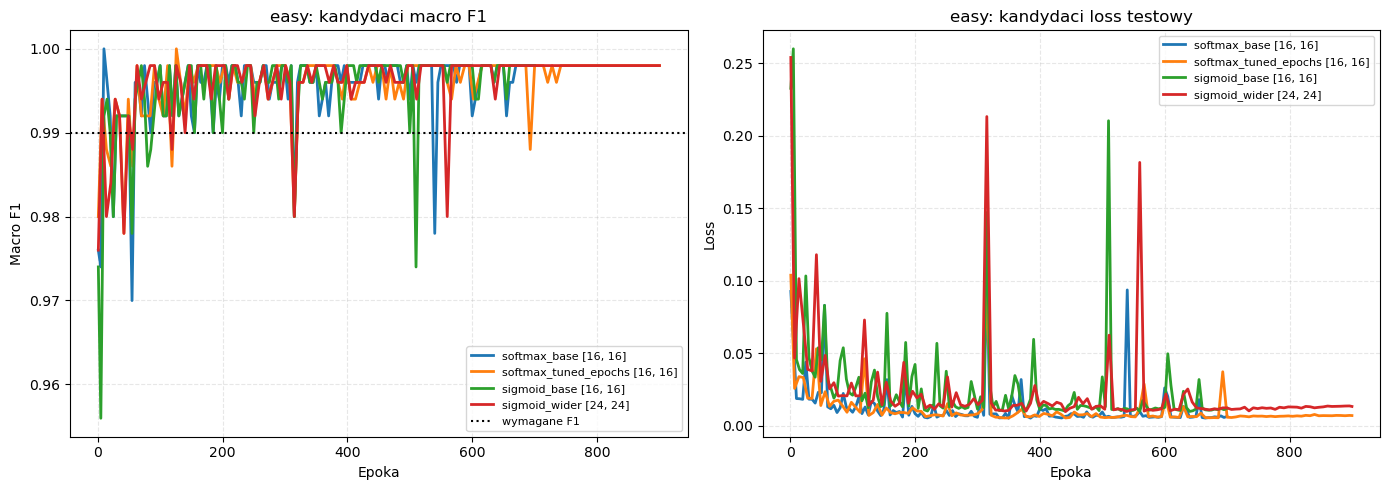

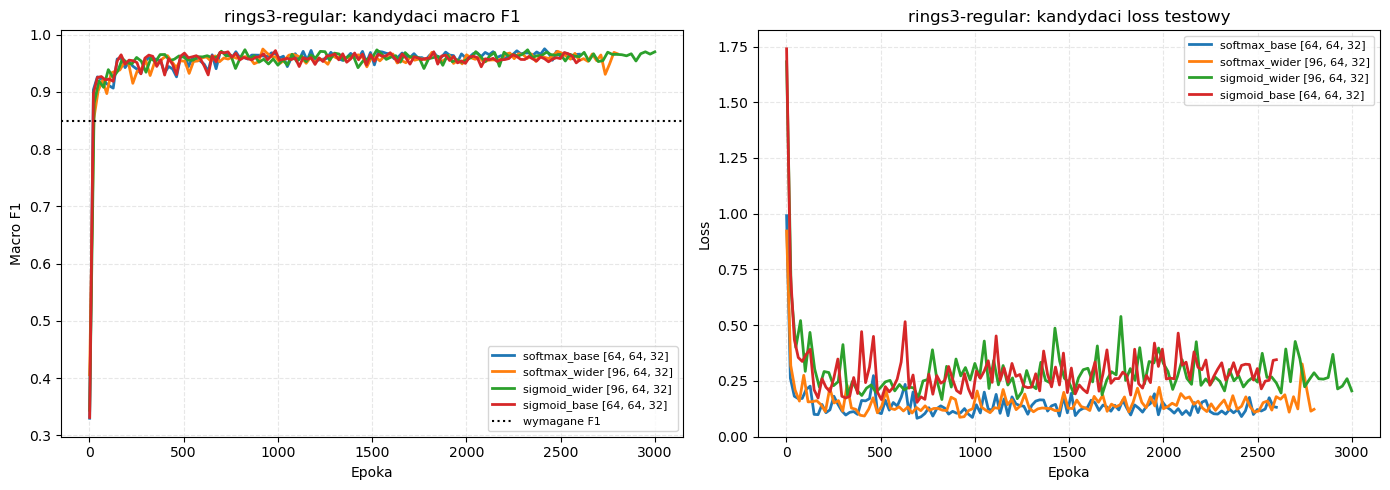

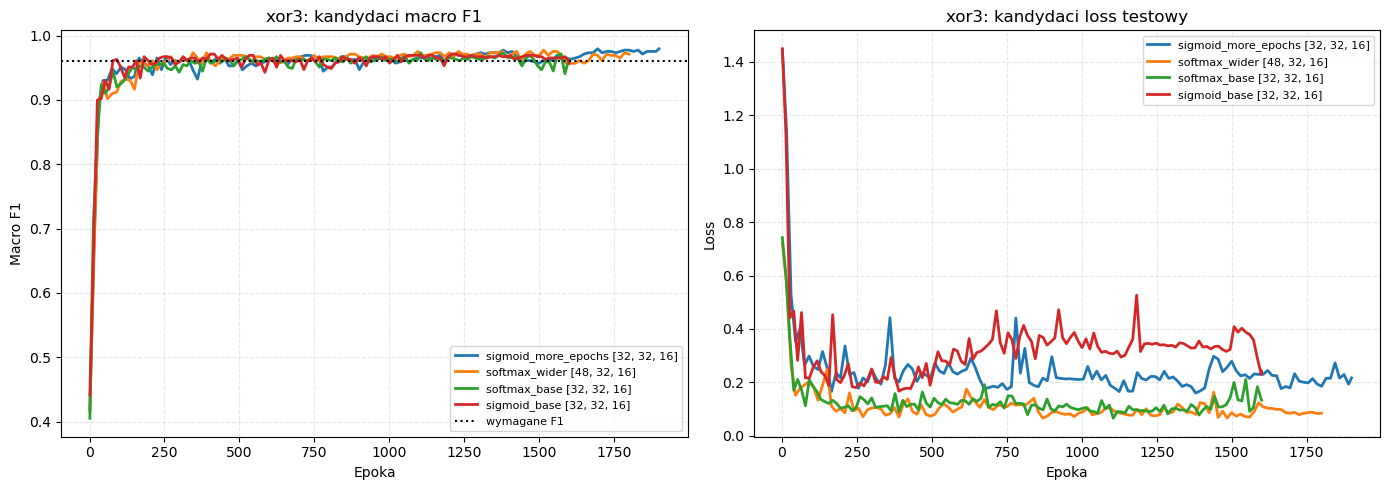


Najlepszy kandydat osobno dla softmax i sigmoid:
       dataset output_activation             variant  hidden_dims  epochs     lr  best_macro_f1  final_macro_f1
          easy           sigmoid        sigmoid_base     [16, 16]     700 0.0500       0.998000        0.998000
          easy           softmax        softmax_base     [16, 16]     700 0.0500       1.000000        0.998000
rings3-regular           sigmoid       sigmoid_wider [96, 64, 32]    3000 0.0022       0.973769        0.970084
rings3-regular           softmax        softmax_base [64, 64, 32]    2600 0.0030       0.975373        0.965935
          xor3           sigmoid sigmoid_more_epochs [32, 32, 16]    1900 0.0250       0.979475        0.979475
          xor3           softmax       softmax_wider [48, 32, 16]    1800 0.0250       0.977437        0.971226

Finalni zwyciezcy dla kazdego zbioru:
       dataset             variant output_activation  hidden_dims  epochs    lr  best_macro_f1  final_macro_f1
          easy  

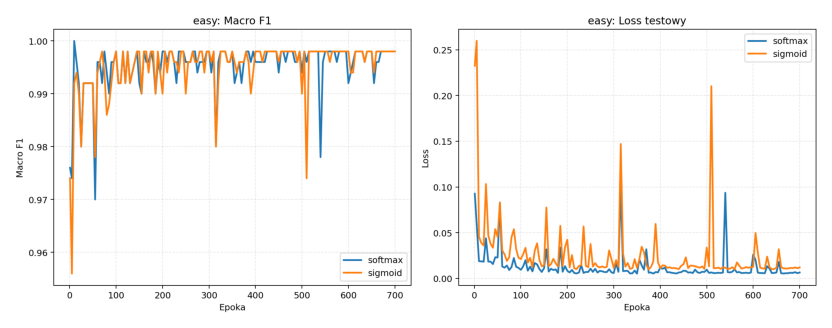


Finalisci dla rings3-regular zapisani do rings3-regular_comparison.png


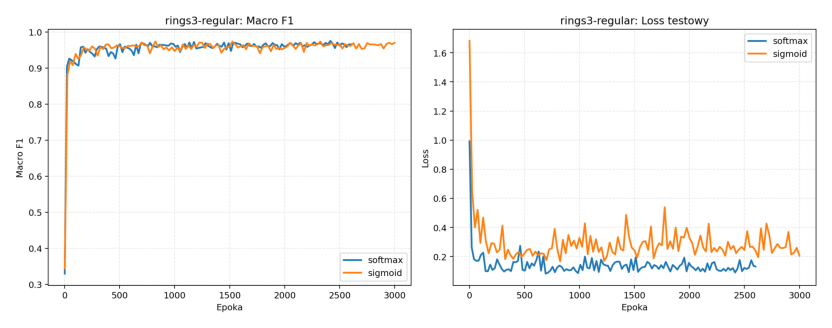


Finalisci dla xor3 zapisani do xor3_comparison.png


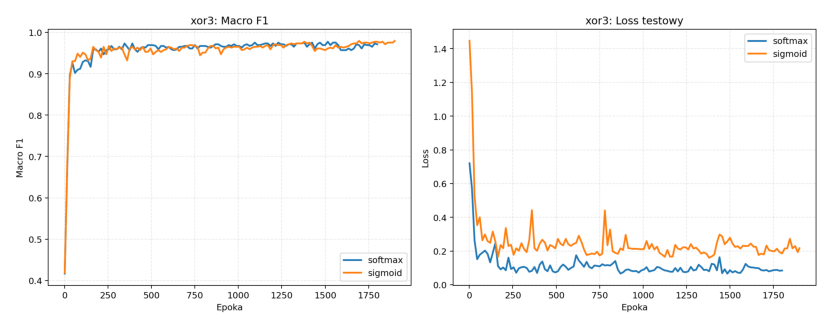

In [12]:
if 'summary_df' not in globals():
    base_dir = Path('.').resolve()
    all_runs, summary_df = run_all_experiments(base_dir)

requirements = {
    'rings3-regular': 0.85,
    'easy': 0.99,
    'xor3': 0.96,
}

print('Bazowe konfiguracje juz spelniaja wymagania:')
baseline_check = summary_df.copy()
baseline_check['required_f1'] = baseline_check['dataset'].map(requirements)
baseline_check['meets_requirement'] = baseline_check['best_macro_f1'] >= baseline_check['required_f1']
print(baseline_check[['dataset', 'variant', 'best_macro_f1', 'required_f1', 'meets_requirement']].to_string(index=False))

if 'datasets' not in globals():
    datasets = {
        name: load_dataset(base_dir, name)
        for name in sorted(requirements)
    }

candidate_configs = [
    RunConfig('easy', 'softmax_base', 'softmax', 'momentum', [16, 16], 'tanh', 700, 32, 0.05, momentum=0.90),
    RunConfig('easy', 'softmax_tuned_epochs', 'softmax', 'momentum', [16, 16], 'tanh', 900, 32, 0.04, momentum=0.90),
    RunConfig('easy', 'sigmoid_base', 'sigmoid', 'momentum', [16, 16], 'tanh', 700, 32, 0.05, momentum=0.90),
    RunConfig('easy', 'sigmoid_wider', 'sigmoid', 'momentum', [24, 24], 'tanh', 900, 32, 0.04, momentum=0.90),
    RunConfig('xor3', 'softmax_base', 'softmax', 'momentum', [32, 32, 16], 'tanh', 1600, 32, 0.03, momentum=0.92),
    RunConfig('xor3', 'softmax_wider', 'softmax', 'momentum', [48, 32, 16], 'tanh', 1800, 32, 0.025, momentum=0.93),
    RunConfig('xor3', 'sigmoid_base', 'sigmoid', 'momentum', [32, 32, 16], 'tanh', 1600, 32, 0.03, momentum=0.92),
    RunConfig('xor3', 'sigmoid_more_epochs', 'sigmoid', 'momentum', [32, 32, 16], 'tanh', 1900, 32, 0.025, momentum=0.93),
    RunConfig('rings3-regular', 'softmax_base', 'softmax', 'rmsprop', [64, 64, 32], 'tanh', 2600, 64, 0.003, decay=0.92),
    RunConfig('rings3-regular', 'softmax_wider', 'softmax', 'rmsprop', [96, 64, 32], 'tanh', 2800, 64, 0.0028, decay=0.92),
    RunConfig('rings3-regular', 'sigmoid_base', 'sigmoid', 'rmsprop', [64, 64, 32], 'tanh', 2600, 64, 0.0025, decay=0.92),
    RunConfig('rings3-regular', 'sigmoid_wider', 'sigmoid', 'rmsprop', [96, 64, 32], 'tanh', 3000, 64, 0.0022, decay=0.92),
]

search_runs = {}
search_rows = []
for config in candidate_configs:
    result = train_single_run(datasets[config.dataset_name], config, seed=SEED)
    search_runs[(config.dataset_name, config.variant_name)] = result
    search_rows.append({
        'dataset': config.dataset_name,
        'variant': config.variant_name,
        'output_activation': config.output_activation,
        'optimizer': config.optimizer_name,
        'hidden_dims': str(config.hidden_dims),
        'epochs': config.epochs,
        'batch_size': config.batch_size,
        'lr': config.lr,
        'best_epoch': result['best']['epoch'],
        'best_macro_f1': result['best']['macro_f1'],
        'final_macro_f1': result['final']['macro_f1'],
    })

search_df = pd.DataFrame(search_rows)
search_df['required_f1'] = search_df['dataset'].map(requirements)
search_df['meets_requirement'] = search_df['best_macro_f1'] >= search_df['required_f1']
search_df = search_df.sort_values(['dataset', 'best_macro_f1', 'final_macro_f1'], ascending=[True, False, False]).reset_index(drop=True)

print('\nKandydaci po lekkim dostrojeniu architektury i epok:')
print(search_df[['dataset', 'variant', 'output_activation', 'hidden_dims', 'epochs', 'lr', 'best_macro_f1', 'final_macro_f1', 'meets_requirement']].to_string(index=False))

output_dir = base_dir / 'outputs'
ensure_dir(output_dir)

for dataset_name in sorted(search_df['dataset'].unique()):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    subset = search_df[search_df['dataset'] == dataset_name]
    for _, row in subset.iterrows():
        run = search_runs[(dataset_name, row['variant'])]
        label = '{} {}'.format(row['variant'], row['hidden_dims'])
        axes[0].plot(run['history']['epoch'], run['history']['test_macro_f1'], label=label, linewidth=2)
        axes[1].plot(run['history']['epoch'], run['history']['test_loss'], label=label, linewidth=2)
    axes[0].axhline(requirements[dataset_name], color='black', linestyle=':', linewidth=1.5, label='wymagane F1')
    axes[0].set_title('{}: kandydaci macro F1'.format(dataset_name))
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('Macro F1')
    axes[0].grid(alpha=0.3, linestyle='--')
    axes[0].legend(fontsize=8)
    axes[1].set_title('{}: kandydaci loss testowy'.format(dataset_name))
    axes[1].set_xlabel('Epoka')
    axes[1].set_ylabel('Loss')
    axes[1].grid(alpha=0.3, linestyle='--')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    candidate_plot_path = output_dir / '{}_candidate_search.png'.format(dataset_name)
    plt.savefig(candidate_plot_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

best_per_activation = (
    search_df.sort_values(['dataset', 'output_activation', 'best_macro_f1', 'final_macro_f1', 'epochs'], ascending=[True, True, False, False, True])
    .groupby(['dataset', 'output_activation'], as_index=False)
    .first()
)
overall_winners = (
    search_df.sort_values(['dataset', 'best_macro_f1', 'final_macro_f1', 'epochs'], ascending=[True, False, False, True])
    .groupby('dataset', as_index=False)
    .first()
)

print('\nNajlepszy kandydat osobno dla softmax i sigmoid:')
print(best_per_activation[['dataset', 'output_activation', 'variant', 'hidden_dims', 'epochs', 'lr', 'best_macro_f1', 'final_macro_f1']].to_string(index=False))

print('\nFinalni zwyciezcy dla kazdego zbioru:')
print(overall_winners[['dataset', 'variant', 'output_activation', 'hidden_dims', 'epochs', 'lr', 'best_macro_f1', 'final_macro_f1']].to_string(index=False))

for dataset_name in sorted(overall_winners['dataset'].unique()):
    best_softmax_variant = best_per_activation[(best_per_activation['dataset'] == dataset_name) & (best_per_activation['output_activation'] == 'softmax')]['variant'].iloc[0]
    best_sigmoid_variant = best_per_activation[(best_per_activation['dataset'] == dataset_name) & (best_per_activation['output_activation'] == 'sigmoid')]['variant'].iloc[0]
    best_softmax_run = search_runs[(dataset_name, best_softmax_variant)]
    best_sigmoid_run = search_runs[(dataset_name, best_sigmoid_variant)]
    final_plot_path = plot_history(dataset_name, best_softmax_run, best_sigmoid_run, output_dir)
    print('\nFinalisci dla {} zapisani do {}'.format(dataset_name, final_plot_path.name))
    image = plt.imread(final_plot_path)
    plt.figure(figsize=(12, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.show()


## Konfiguracje, ktore osiagnely wymagany prog F1

### easy
- softmax_base: siec [16, 16], tanh w warstwach ukrytych, softmax na wyjsciu, optimizer momentum, 700 epok, batch size = 32, learning rate = 0.05, momentum = 0.90
- softmax_tuned_epochs: siec [16, 16], tanh w warstwach ukrytych, softmax na wyjsciu, optimizer momentum, 900 epok, batch size = 32, learning rate = 0.04, momentum = 0.90
- sigmoid_base: siec [16, 16], tanh w warstwach ukrytych, sigmoid na wyjsciu, optimizer momentum, 700 epok, batch size = 32, learning rate = 0.05, momentum = 0.90
- sigmoid_wider: siec [24, 24], tanh w warstwach ukrytych, sigmoid na wyjsciu, optimizer momentum, 900 epok, batch size = 32, learning rate = 0.04, momentum = 0.90

### xor3
- softmax_base: siec [32, 32, 16], tanh w warstwach ukrytych, softmax na wyjsciu, optimizer momentum, 1600 epok, batch size = 32, learning rate = 0.03, momentum = 0.92
- softmax_wider: siec [48, 32, 16], tanh w warstwach ukrytych, softmax na wyjsciu, optimizer momentum, 1800 epok, batch size = 32, learning rate = 0.025, momentum = 0.93
- sigmoid_base: siec [32, 32, 16], tanh w warstwach ukrytych, sigmoid na wyjsciu, optimizer momentum, 1600 epok, batch size = 32, learning rate = 0.03, momentum = 0.92
- sigmoid_more_epochs: siec [32, 32, 16], tanh w warstwach ukrytych, sigmoid na wyjsciu, optimizer momentum, 1900 epok, batch size = 32, learning rate = 0.025, momentum = 0.93

### rings3-regular
- softmax_base: siec [64, 64, 32], tanh w warstwach ukrytych, softmax na wyjsciu, optimizer rmsprop, 2600 epok, batch size = 64, learning rate = 0.003, decay = 0.92
- softmax_wider: siec [96, 64, 32], tanh w warstwach ukrytych, softmax na wyjsciu, optimizer rmsprop, 2800 epok, batch size = 64, learning rate = 0.0028, decay = 0.92
- sigmoid_base: siec [64, 64, 32], tanh w warstwach ukrytych, sigmoid na wyjsciu, optimizer rmsprop, 2600 epok, batch size = 64, learning rate = 0.0025, decay = 0.92
- sigmoid_wider: siec [96, 64, 32], tanh w warstwach ukrytych, sigmoid na wyjsciu, optimizer rmsprop, 3000 epok, batch size = 64, learning rate = 0.0022, decay = 0.92
